In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import chi2_contingency

import shap

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
percorso_file = '/Users/carlo_air_2021/Desktop/Magistrale/Machine Learning/mushrooms_decoded.csv'

In [3]:
df = pd.read_csv(percorso_file)

In [4]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,poisonous,convex,smooth,brown,bruises,pungent,free,close,narrow,black,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
1,edible,convex,smooth,yellow,bruises,almond,free,close,broad,black,...,smooth,white,white,partial,white,one,pendant,brown,numerous,grasses
2,edible,bell,smooth,white,bruises,anise,free,close,broad,brown,...,smooth,white,white,partial,white,one,pendant,brown,numerous,meadows
3,poisonous,convex,scaly,white,bruises,pungent,free,close,narrow,brown,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
4,edible,convex,smooth,gray,no,NaN,free,crowded,broad,black,...,smooth,white,white,partial,white,one,evanescent,brown,abundant,grasses


In [5]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

# 1. Pulizia iniziale

In [6]:
df = df.replace("?", np.nan)

In [7]:
df.isna().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                        3528
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [8]:
df['odor'] = df['odor'].fillna('odorless')
df['odor'].isna().sum()

np.int64(0)

In [9]:
df['ring-number'] = df['ring-number'].fillna('ringless')
df['ring-number'].isna().sum()

np.int64(0)

In [10]:
df['ring-type'] = df['ring-type'].fillna('ringless')
df['ring-type'].isna().sum()

np.int64(0)

In [11]:
df.isna().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [12]:
df.duplicated().sum()
df = df.drop_duplicates()

In [13]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,poisonous,convex,smooth,brown,bruises,pungent,free,close,narrow,black,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
1,edible,convex,smooth,yellow,bruises,almond,free,close,broad,black,...,smooth,white,white,partial,white,one,pendant,brown,numerous,grasses
2,edible,bell,smooth,white,bruises,anise,free,close,broad,brown,...,smooth,white,white,partial,white,one,pendant,brown,numerous,meadows
3,poisonous,convex,scaly,white,bruises,pungent,free,close,narrow,brown,...,smooth,white,white,partial,white,one,pendant,black,scattered,urban
4,edible,convex,smooth,gray,no,odorless,free,crowded,broad,black,...,smooth,white,white,partial,white,one,evanescent,brown,abundant,grasses


# 2. Analisi distribuzione target

In [14]:
target_counts = df["class"].value_counts()
target_perc = df["class"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Frequency": target_counts,
    "Percentage": target_perc.round(2)
})

target_summary

,Frequency,Percentage
class,,
edible,4208,51.8
poisonous,3916,48.2


# 3. Analisi della varianza

In [15]:
df.nunique()

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [16]:
df = df.drop(columns=["veil-type"])

# 4. Rimozione di stalk_root

In [17]:
df = df.drop(columns=["stalk-root"])


# 5. Mapping the target variable

In [18]:
df['class'] = df['class'].map({"edible": 0, "poisonous": 1})


In [19]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,convex,smooth,brown,bruises,pungent,free,close,narrow,black,...,smooth,smooth,white,white,white,one,pendant,black,scattered,urban
1,0,convex,smooth,yellow,bruises,almond,free,close,broad,black,...,smooth,smooth,white,white,white,one,pendant,brown,numerous,grasses
2,0,bell,smooth,white,bruises,anise,free,close,broad,brown,...,smooth,smooth,white,white,white,one,pendant,brown,numerous,meadows
3,1,convex,scaly,white,bruises,pungent,free,close,narrow,brown,...,smooth,smooth,white,white,white,one,pendant,black,scattered,urban
4,0,convex,smooth,gray,no,odorless,free,crowded,broad,black,...,smooth,smooth,white,white,white,one,evanescent,brown,abundant,grasses


# 6. Rimozione duplicati

In [20]:
print(f"\nNumber of rows before duplicate removal: {len(df)}")
df = df.drop_duplicates()
print(f"Number of rows after duplicate removal: {len(df)}")
print(f"Duplicates removed: {8124 - len(df)}")

df_clean = df.copy()


Number of rows before duplicate removal: 8124
Number of rows after duplicate removal: 8124
Duplicates removed: 0


# 7. EDA


=== TARGET VARIABLE DISTRIBUTION ===

Absolute distribution:
class
0    4208
1    3916
Name: count, dtype: int64

Percentage distribution:
class
0    51.797144
1    48.202856
Name: proportion, dtype: float64

            Class  Count Percentage
0     Edible (0)   4208      51.8%
1  Poisonous (1)   3916      48.2%

=== CORRELATION MATRIX CALCULATION ===

Correlation matrix completed
             cap-shape  cap-surface  cap-color   bruises      odor  \
cap-shape     1.000000     0.203721   0.171431  0.255606  0.245516   
cap-surface   0.203721     1.000000   0.225273  0.134377  0.238446   
cap-color     0.171431     0.225273   1.000000  0.217648  0.332026   
bruises       0.255606     0.134377   0.217648  1.000000  0.660906   
odor          0.245516     0.238446   0.332026  0.660906  1.000000   

             gill-attachment  gill-spacing  gill-size  gill-color  \
cap-shape           0.154978      0.081702   0.346823    0.235100   
cap-surface         0.210841      0.338222   0.277414  

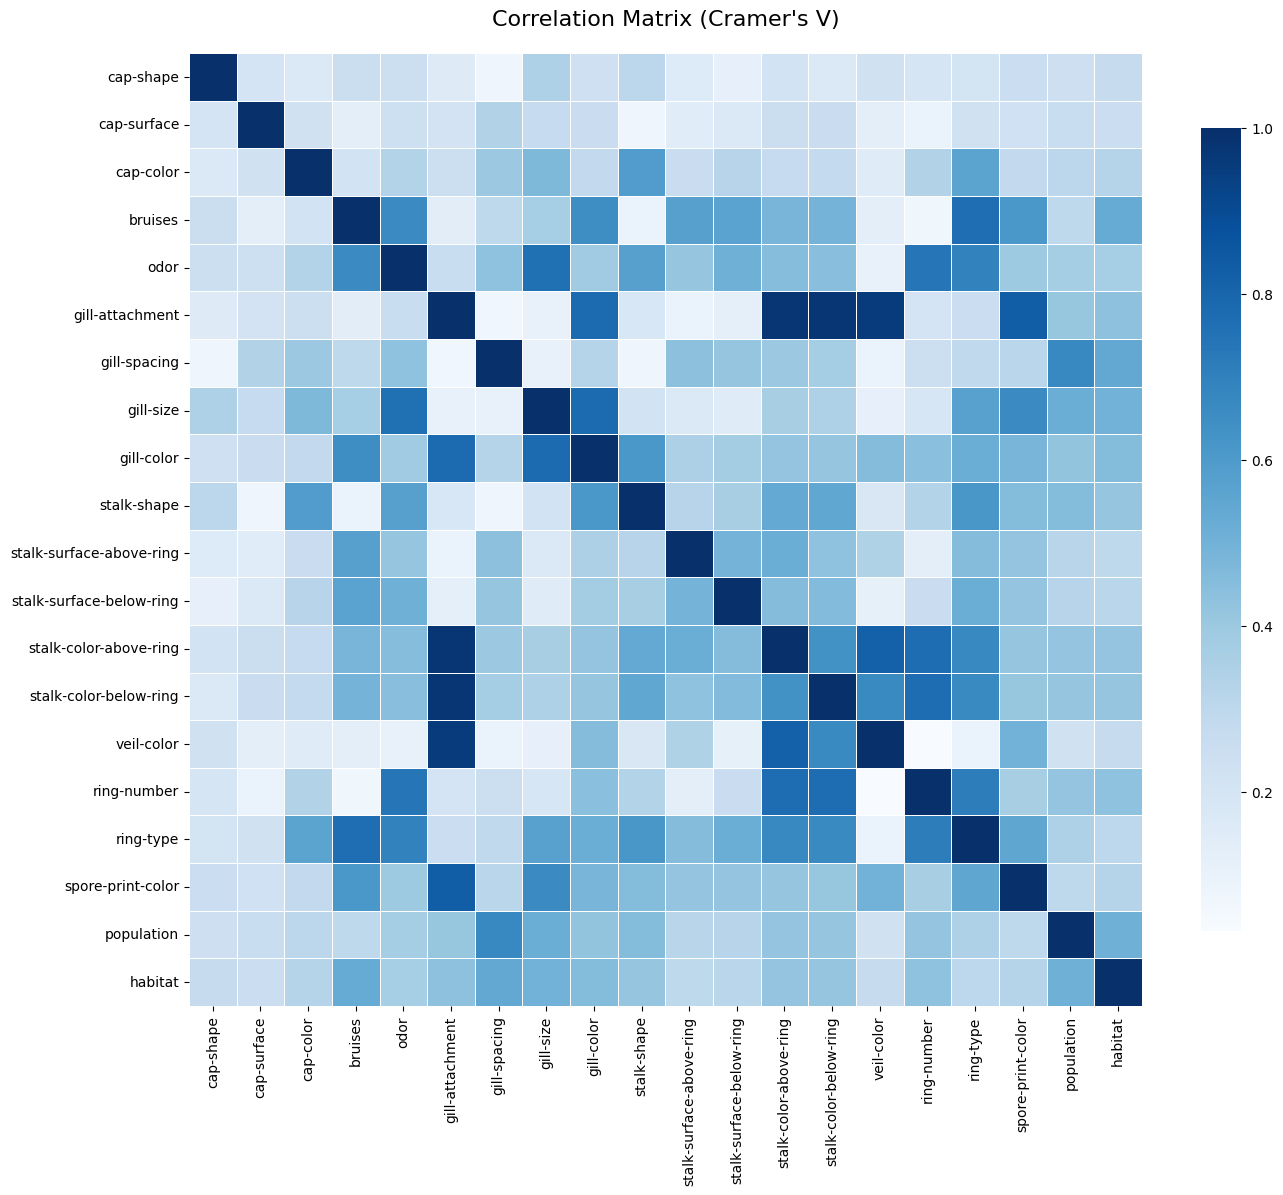

In [21]:
print("\n=== TARGET VARIABLE DISTRIBUTION ===")
target_dist = df['class'].value_counts()
target_dist_pct = df['class'].value_counts(normalize=True) * 100

print("\nAbsolute distribution:")
print(target_dist)
print("\nPercentage distribution:")
print(target_dist_pct)

dist_table = pd.DataFrame({
    'Class': ['Edible (0)', 'Poisonous (1)'],
    'Count': [target_dist[0], target_dist[1]],
    'Percentage': [f"{target_dist_pct[0]:.1f}%", f"{target_dist_pct[1]:.1f}%"]
})
print("\n", dist_table)

def cramers_v(x, y):
    """Calculates Cramer's V between two categorical variables"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

print("\n=== CORRELATION MATRIX CALCULATION ===")
categorical_cols = df.columns.drop('class')
correlation_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    columns=categorical_cols,
    index=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            correlation_matrix.loc[col1, col2] = 1.0
        else:
            correlation_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

print("\nCorrelation matrix completed")
print(correlation_matrix.head())

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='Blues', square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Cramer\'s V)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print("\n=== PREPARAZIONE DATI PER MODELLAZIONE ===")

df_encoded = df.copy()

label_encoders = {}
for col in df_encoded.columns:
    if col != 'class':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

print("Encoding completato")
print("\nPrime righe dataset encoded:")
print(df_encoded.head())

print(f"\nNumero righe prima della seconda rimozione: {len(df_encoded)}")
df_encoded = df_encoded.drop_duplicates()
print(f"Numero righe dopo: {len(df_encoded)}")

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

print(f"\nShape finale - X: {X.shape}, y: {y.shape}")


=== PREPARAZIONE DATI PER MODELLAZIONE ===
Encoding completato

Prime righe dataset encoded:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          2            3          0        0     7                1   
1      0          2            3          9        0     0                1   
2      0          0            3          8        0     1                1   
3      1          2            2          8        0     7                1   
4      0          2            3          3        1     6                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-above-ring  \
0             0          1           0  ...                         3   
1             0          0           0  ...                         3   
2             0          0           1  ...                         3   
3             0          1           1  ...                         3   
4             1          0           0  ...                       

In [23]:
print("="*60)
print("TRAINING E VALUTAZIONE - SOLO CROSS-VALIDATION")
print("="*60)

X_full = X.copy()
y_full = y.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'recall', 'precision', 'f1']

print(f"\nDataset completo: {len(X_full)} osservazioni")
print(f"Strategia: 5-Fold Stratified Cross-Validation")
print(f"Distribuzione classi:")
print(f"  Edible (0): {(y_full == 0).sum()} ({(y_full == 0).sum()/len(y_full)*100:.1f}%)")
print(f"  Poisonous (1): {(y_full == 1).sum()} ({(y_full == 1).sum()/len(y_full)*100:.1f}%)")

results = {}

TRAINING E VALUTAZIONE - SOLO CROSS-VALIDATION

Dataset completo: 8124 osservazioni
Strategia: 5-Fold Stratified Cross-Validation
Distribuzione classi:
  Edible (0): 4208 (51.8%)
  Poisonous (1): 3916 (48.2%)



--- Decision Tree Classifier ---

Cross-Validation Results (mean ± std):
  Accuracy:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  Precision: 1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
✓ Modello trainato su tutto il dataset

--- Naive Bayes Classifier ---

Cross-Validation Results (mean ± std):
  Accuracy:  0.9609 ± 0.0058
  Recall:    0.9249 ± 0.0131
  Precision: 0.9934 ± 0.0027
  F1-Score:  0.9579 ± 0.0065
✓ Modello trainato su tutto il dataset

--- Random Forest Classifier ---

Cross-Validation Results (mean ± std):
  Accuracy:  1.0000 ± 0.0000
  Recall:    1.0000 ± 0.0000
  Precision: 1.0000 ± 0.0000
  F1-Score:  1.0000 ± 0.0000
✓ Modello trainato su tutto il dataset

CONFRONTO MODELLI - CROSS-VALIDATION

         Model  Accuracy  Recall  Precision  F1-Score
Decision Tree    1.0000  1.0000     1.0000    1.0000
  Naive Bayes    0.9609  0.9249     0.9934    0.9579
Random Forest    1.0000  1.0000     1.0000    1.0000

✓ Salvato: model_comparison_cv.csv

MIGLIOR MODELLO: Decision 

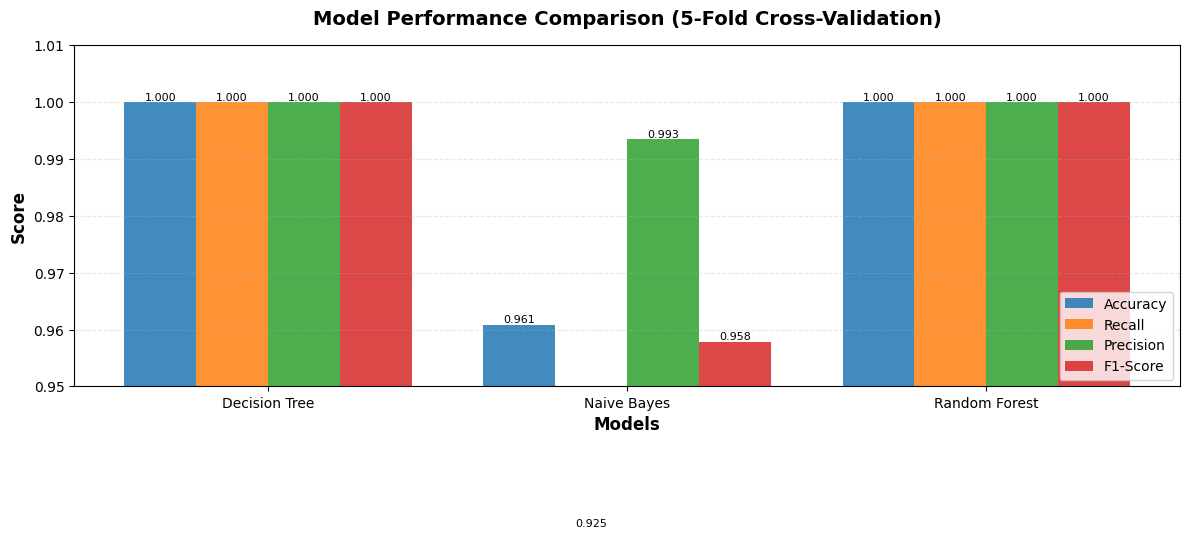

✓ Grafico salvato: model_comparison_cv.png

RISULTATI DETTAGLIATI (Mean ± Std)

         Model        Accuracy          Recall       Precision        F1-Score
Decision Tree 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000
  Naive Bayes 0.9609 ± 0.0058 0.9249 ± 0.0131 0.9934 ± 0.0027 0.9579 ± 0.0065
Random Forest 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000 1.0000 ± 0.0000

✓ Salvato: model_comparison_cv_detailed.csv

✓ TRAINING E VALUTAZIONE COMPLETATI!


In [24]:
# =============================================================================
# 8.1 DECISION TREE
# =============================================================================
print("\n" + "="*60)
print("--- Decision Tree Classifier ---")
print("="*60)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=20,
    random_state=42
)

# Cross-validation
dt_scores = cross_validate(dt_model, X_full, y_full, 
                          cv=cv, scoring=scoring_metrics, 
                          return_train_score=False)

results['Decision Tree'] = {
    'Accuracy': dt_scores['test_accuracy'].mean(),
    'Accuracy_std': dt_scores['test_accuracy'].std(),
    'Recall': dt_scores['test_recall'].mean(),
    'Recall_std': dt_scores['test_recall'].std(),
    'Precision': dt_scores['test_precision'].mean(),
    'Precision_std': dt_scores['test_precision'].std(),
    'F1-Score': dt_scores['test_f1'].mean(),
    'F1_std': dt_scores['test_f1'].std()
}

print(f"\nCross-Validation Results (mean ± std):")
print(f"  Accuracy:  {results['Decision Tree']['Accuracy']:.4f} ± {results['Decision Tree']['Accuracy_std']:.4f}")
print(f"  Recall:    {results['Decision Tree']['Recall']:.4f} ± {results['Decision Tree']['Recall_std']:.4f}")
print(f"  Precision: {results['Decision Tree']['Precision']:.4f} ± {results['Decision Tree']['Precision_std']:.4f}")
print(f"  F1-Score:  {results['Decision Tree']['F1-Score']:.4f} ± {results['Decision Tree']['F1_std']:.4f}")

# Train finale su tutto il dataset per analisi successive
dt_model.fit(X_full, y_full)
print("✓ Modello trainato su tutto il dataset")

# =============================================================================
# 8.2 NAIVE BAYES
# =============================================================================
print("\n" + "="*60)
print("--- Naive Bayes Classifier ---")
print("="*60)

nb_model = CategoricalNB()

# Cross-validation
nb_scores = cross_validate(nb_model, X_full, y_full, 
                          cv=cv, scoring=scoring_metrics, 
                          return_train_score=False)

results['Naive Bayes'] = {
    'Accuracy': nb_scores['test_accuracy'].mean(),
    'Accuracy_std': nb_scores['test_accuracy'].std(),
    'Recall': nb_scores['test_recall'].mean(),
    'Recall_std': nb_scores['test_recall'].std(),
    'Precision': nb_scores['test_precision'].mean(),
    'Precision_std': nb_scores['test_precision'].std(),
    'F1-Score': nb_scores['test_f1'].mean(),
    'F1_std': nb_scores['test_f1'].std()
}

print(f"\nCross-Validation Results (mean ± std):")
print(f"  Accuracy:  {results['Naive Bayes']['Accuracy']:.4f} ± {results['Naive Bayes']['Accuracy_std']:.4f}")
print(f"  Recall:    {results['Naive Bayes']['Recall']:.4f} ± {results['Naive Bayes']['Recall_std']:.4f}")
print(f"  Precision: {results['Naive Bayes']['Precision']:.4f} ± {results['Naive Bayes']['Precision_std']:.4f}")
print(f"  F1-Score:  {results['Naive Bayes']['F1-Score']:.4f} ± {results['Naive Bayes']['F1_std']:.4f}")

# Train finale su tutto il dataset
nb_model.fit(X_full, y_full)
print("✓ Modello trainato su tutto il dataset")

# =============================================================================
# 8.3 RANDOM FOREST
# =============================================================================
print("\n" + "="*60)
print("--- Random Forest Classifier ---")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',  # Information Gain
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

# Cross-validation
rf_scores = cross_validate(rf_model, X_full, y_full, 
                          cv=cv, scoring=scoring_metrics, 
                          return_train_score=False)

results['Random Forest'] = {
    'Accuracy': rf_scores['test_accuracy'].mean(),
    'Accuracy_std': rf_scores['test_accuracy'].std(),
    'Recall': rf_scores['test_recall'].mean(),
    'Recall_std': rf_scores['test_recall'].std(),
    'Precision': rf_scores['test_precision'].mean(),
    'Precision_std': rf_scores['test_precision'].std(),
    'F1-Score': rf_scores['test_f1'].mean(),
    'F1_std': rf_scores['test_f1'].std()
}

print(f"\nCross-Validation Results (mean ± std):")
print(f"  Accuracy:  {results['Random Forest']['Accuracy']:.4f} ± {results['Random Forest']['Accuracy_std']:.4f}")
print(f"  Recall:    {results['Random Forest']['Recall']:.4f} ± {results['Random Forest']['Recall_std']:.4f}")
print(f"  Precision: {results['Random Forest']['Precision']:.4f} ± {results['Random Forest']['Precision_std']:.4f}")
print(f"  F1-Score:  {results['Random Forest']['F1-Score']:.4f} ± {results['Random Forest']['F1_std']:.4f}")

# Train finale su tutto il dataset
rf_model.fit(X_full, y_full)
print("✓ Modello trainato su tutto il dataset")

# Questo sarà il modello per SHAP
rf_final = rf_model

# =============================================================================
# CONFRONTO RISULTATI
# =============================================================================
print("\n" + "="*60)
print("CONFRONTO MODELLI - CROSS-VALIDATION")
print("="*60)

# Tabella comparativa (solo medie)
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()]
})

print("\n", results_df.round(4).to_string(index=False))

# Salva CSV
results_df.to_csv('model_comparison_cv.csv', index=False)
print("\n✓ Salvato: model_comparison_cv.csv")

# Identifica il miglior modello
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1 = results_df['F1-Score'].max()

print(f"\n{'='*60}")
print(f"MIGLIOR MODELLO: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"{'='*60}")

# =============================================================================
# GRAFICO COMPARATIVO
# =============================================================================
print("\nGenerazione grafico comparativo...")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.85)
    
    # Aggiungi valori sopra le barre
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (5-Fold Cross-Validation)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'])
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim([0.95, 1.01])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('model_comparison_cv.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico salvato: model_comparison_cv.png")

# =============================================================================
# TABELLA DETTAGLIATA CON DEVIAZIONI STANDARD
# =============================================================================
print("\n" + "="*60)
print("RISULTATI DETTAGLIATI (Mean ± Std)")
print("="*60)

detailed_results = []
for model_name in results.keys():
    detailed_results.append({
        'Model': model_name,
        'Accuracy': f"{results[model_name]['Accuracy']:.4f} ± {results[model_name]['Accuracy_std']:.4f}",
        'Recall': f"{results[model_name]['Recall']:.4f} ± {results[model_name]['Recall_std']:.4f}",
        'Precision': f"{results[model_name]['Precision']:.4f} ± {results[model_name]['Precision_std']:.4f}",
        'F1-Score': f"{results[model_name]['F1-Score']:.4f} ± {results[model_name]['F1_std']:.4f}"
    })

detailed_df = pd.DataFrame(detailed_results)
print("\n", detailed_df.to_string(index=False))

# Salva anche questa versione
detailed_df.to_csv('model_comparison_cv_detailed.csv', index=False)
print("\n✓ Salvato: model_comparison_cv_detailed.csv")

print("\n" + "="*60)
print("✓ TRAINING E VALUTAZIONE COMPLETATI!")
print("="*60)

In [25]:
"""print("\n" + "="*60)
print("TUNING FINALE - RANDOM FOREST")
print("="*60)

# Training su tutto il train set
rf_final = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

# Predizioni probabilistiche sul test set
y_pred_proba = rf_final.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"\nAUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Trova threshold ottimale per minimizzare falsi negativi
# Cerchiamo il threshold che massimizza recall mantenendo buona precision
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.3f}")

# Proviamo con threshold = 0.3 come nel documento
custom_threshold = 0.3
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"\n--- Performance con threshold = {custom_threshold} ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_custom):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_custom):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
print("\nConfusion Matrix:")
print(cm)
print(f"\nFalse Negatives (critico): {cm[1, 0]}")
print(f"False Positives: {cm[0, 1]}")

# Visualizza confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Confusion Matrix (threshold = {custom_threshold})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Confronto threshold standard vs custom
y_pred_standard = rf_final.predict(X_test)
print(f"\n--- Confronto threshold 0.5 vs {custom_threshold} ---")
print("\nThreshold = 0.5:")
print(f"  False Negatives: {confusion_matrix(y_test, y_pred_standard)[1, 0]}")
print(f"  Recall: {recall_score(y_test, y_pred_standard):.4f}")
print(f"\nThreshold = {custom_threshold}:")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  Recall: {recall_score(y_test, y_pred_custom):.4f}")"""

'print("\n" + "="*60)\nprint("TUNING FINALE - RANDOM FOREST")\nprint("="*60)\n\n# Training su tutto il train set\nrf_final = RandomForestClassifier(\n    n_estimators=100,\n    criterion=\'entropy\',\n    max_depth=10,\n    min_samples_split=20,\n    random_state=42,\n    n_jobs=-1\n)\n\nrf_final.fit(X_train, y_train)\n\n# Predizioni probabilistiche sul test set\ny_pred_proba = rf_final.predict_proba(X_test)[:, 1]\n\n# ROC Curve\nfpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)\nroc_auc = auc(fpr, tpr)\n\nprint(f"\nAUC Score: {roc_auc:.4f}")\n\n# Plot ROC Curve\nplt.figure(figsize=(10, 8))\nplt.plot(fpr, tpr, color=\'darkorange\', lw=2, \n         label=f\'ROC curve (AUC = {roc_auc:.3f})\')\nplt.plot([0, 1], [0, 1], color=\'navy\', lw=2, linestyle=\'--\', \n         label=\'Random Classifier\')\nplt.xlim([0.0, 1.0])\nplt.ylim([0.0, 1.05])\nplt.xlabel(\'False Positive Rate\', fontsize=12)\nplt.ylabel(\'True Positive Rate\', fontsize=12)\nplt.title(\'ROC Curve - Random Forest\', fo

# --- XAI ---

In [26]:
print("="*60)
print("EXPLAINABLE AI - SHAP ANALYSIS")
print("="*60)
print("Model: Random Forest")

print(f"\nRandom Forest Parameters:")
print(f"  n_estimators: {rf_final.n_estimators}")
print(f"  criterion: {rf_final.criterion}")
print(f"  max_depth: {rf_final.max_depth}")
print(f"  min_samples_split: {rf_final.min_samples_split}")

# SAMPLE PREPARATION FOR SHAP

X_sample = X_full.sample(n=500, random_state=42)
y_sample = y_full.loc[X_sample.index]

X_sample_array = X_sample.values
feature_names = X_sample.columns.tolist()

print(f"\nSample for SHAP: {len(X_sample)} observations")
print(f"X_sample shape: {X_sample_array.shape}")
print(f"Class distribution in sample:")
print(f"  Edible (0): {(y_sample == 0).sum()} ({(y_sample == 0).sum()/len(y_sample)*100:.1f}%)")
print(f"  Poisonous (1): {(y_sample == 1).sum()} ({(y_sample == 1).sum()/len(y_sample)*100:.1f}%)")

# CALCULATION OF SHAP VALUES

print("\nCalculating SHAP values (may take 1-2 minutes)...")
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_sample_array)

print(f"\nshap_values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List of {len(shap_values)} arrays")
    print(f"  Class 0 (Edible) shape: {shap_values[0].shape}")
    print(f"  Class 1 (Poisonous) shape: {shap_values[1].shape}")
elif isinstance(shap_values, np.ndarray):
    print(f"Array shape: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        print("  Converting from 3D array to list...")
        shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
        print(f"  List of {len(shap_values)} arrays")

print("✓ SHAP values calculated!\n")

EXPLAINABLE AI - SHAP ANALYSIS
Model: Random Forest

Random Forest Parameters:
  n_estimators: 100
  criterion: entropy
  max_depth: 10
  min_samples_split: 20

Sample for SHAP: 500 observations
X_sample shape: (500, 20)
Class distribution in sample:
  Edible (0): 257 (51.4%)
  Poisonous (1): 243 (48.6%)

Calculating SHAP values (may take 1-2 minutes)...

shap_values type: <class 'numpy.ndarray'>
Array shape: (500, 20, 2)
  Converting from 3D array to list...
  List of 2 arrays
✓ SHAP values calculated!




1. BEESWARM PLOT - CLASS 'POISONOUS'


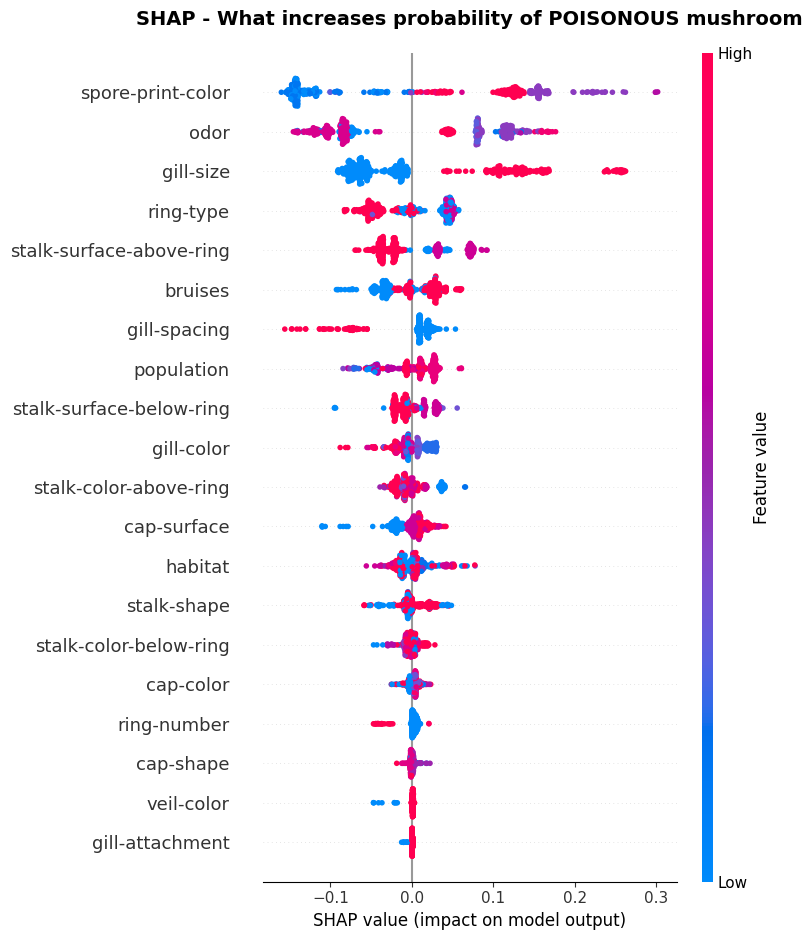

✓ Chart saved: shap_beeswarm_poisonous.png


In [27]:
# 1. BEESWARM PLOT - POISONOUS CLASS (1)

print("\n" + "="*60)
print("1. BEESWARM PLOT - CLASS 'POISONOUS'")
print("="*60)

# Class 1 = Poisonous (most critical)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values[1], X_sample_array, 
                  feature_names=feature_names,
                  show=False, 
                  max_display=20)
plt.title("SHAP - What increases probability of POISONOUS mushroom", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm_poisonous.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: shap_beeswarm_poisonous.png")


2. BEESWARM PLOT - CLASS 'EDIBLE'


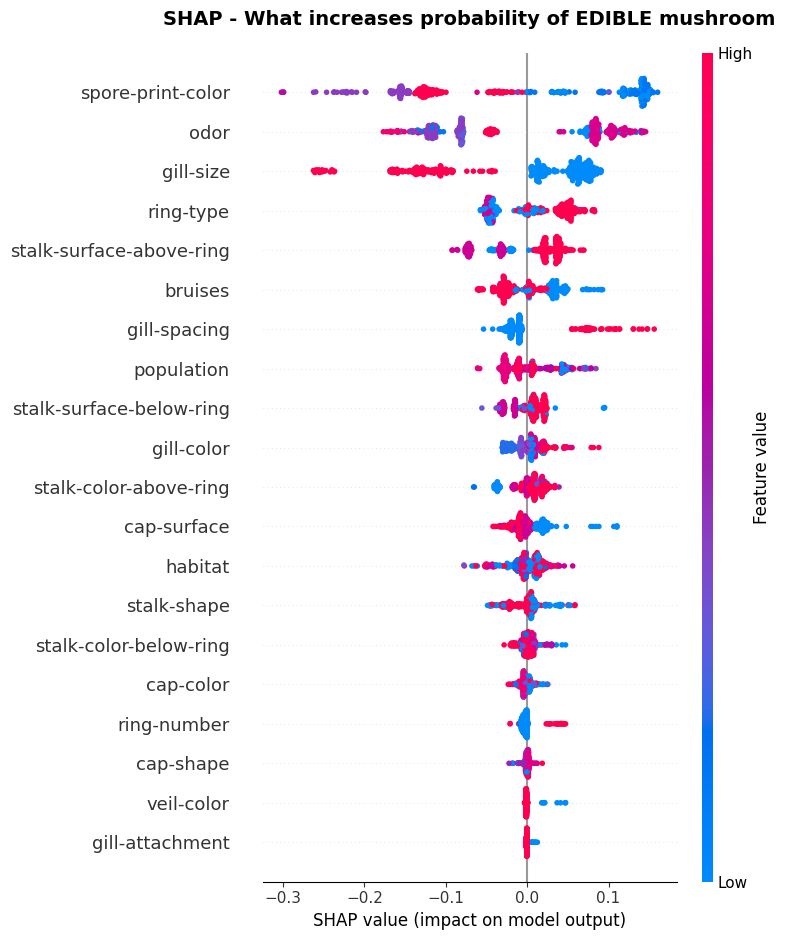

✓ Chart saved: shap_beeswarm_edible.png


In [28]:
# 2. BEESWARM PLOT - EDIBLE CLASS (0)

print("\n" + "="*60)
print("2. BEESWARM PLOT - CLASS 'EDIBLE'")
print("="*60)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values[0], X_sample_array, 
                  feature_names=feature_names,
                  show=False, 
                  max_display=20)
plt.title("SHAP - What increases probability of EDIBLE mushroom", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm_edible.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: shap_beeswarm_edible.png")


3. WATERFALL PLOTS - SPECIFIC EXAMPLES

>> Example 1: EDIBLE mushroom (correctly classified)
   Prediction: Edible (0)
   True class: Edible (0)
   Poisonous probability: 0.0000


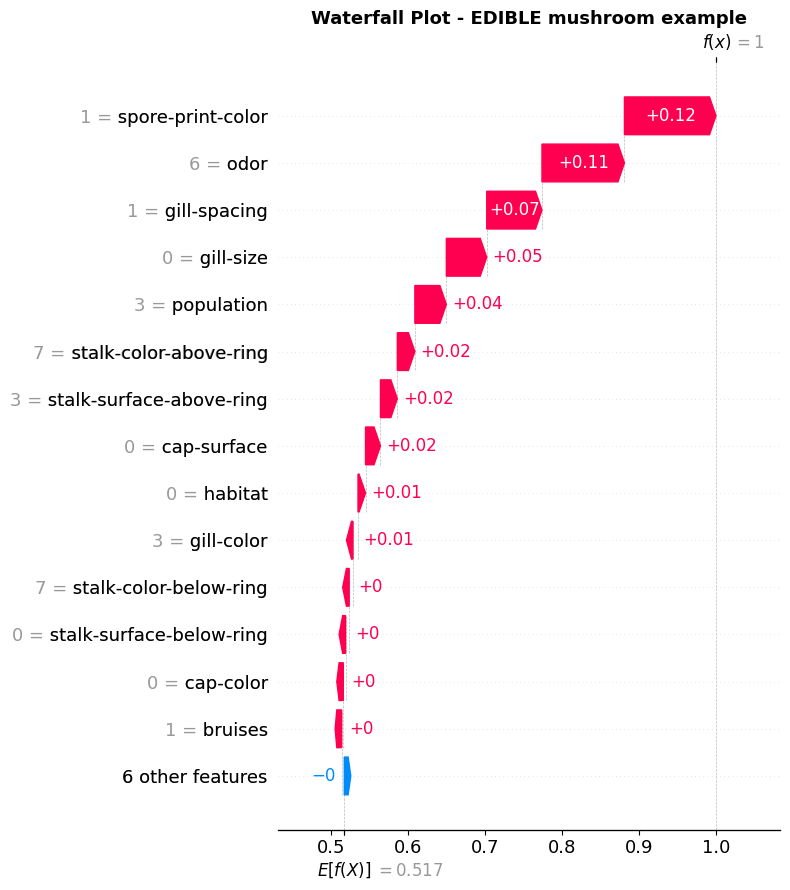

   ✓ Chart saved: shap_waterfall_edible.png

>> Example 2: POISONOUS mushroom (correctly classified)
   Prediction: Poisonous (1)
   True class: Poisonous (1)
   Poisonous probability: 1.0000


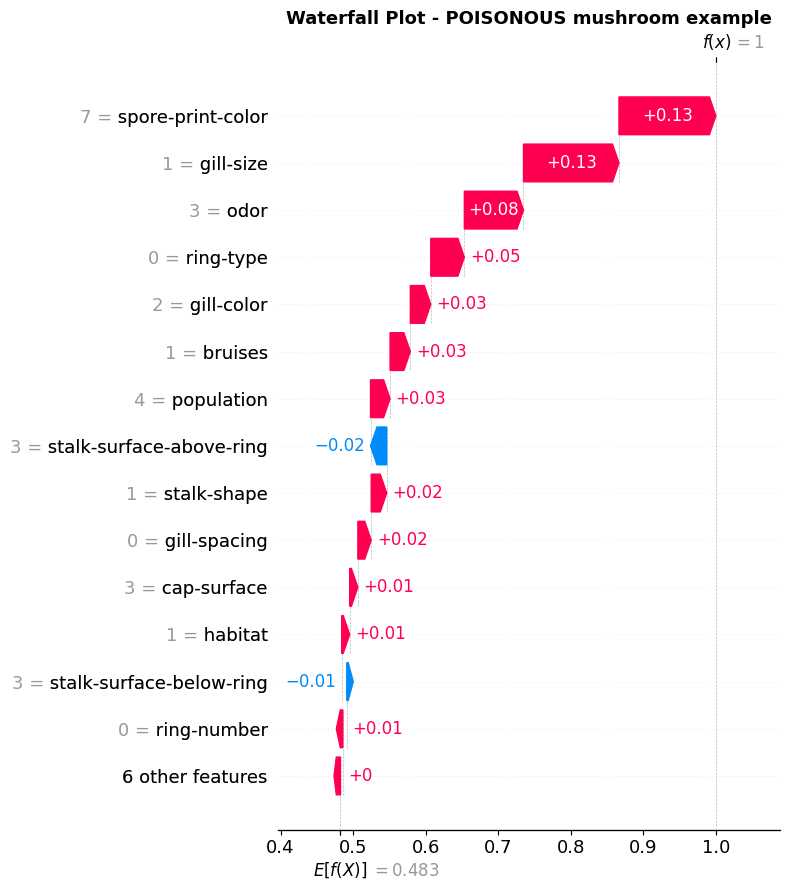

   ✓ Chart saved: shap_waterfall_poisonous.png

>> No classification errors in the sample!


In [29]:
# 3. WATERFALL PLOTS - EXAMPLES FOR EACH CLASS

print("\n" + "="*60)
print("3. WATERFALL PLOTS - SPECIFIC EXAMPLES")
print("="*60)

predictions = rf_final.predict(X_sample_array)

# Example 1: EDIBLE mushroom correctly classified
edible_correct = np.where((predictions == 0) & (y_sample == 0))[0]
if len(edible_correct) > 0:
    idx = edible_correct[0]
    
    print(f"\n>> Example 1: EDIBLE mushroom (correctly classified)")
    print(f"   Prediction: Edible (0)")
    print(f"   True class: Edible (0)")
    print(f"   Poisonous probability: {rf_final.predict_proba(X_sample_array[idx:idx+1])[0][1]:.4f}")
    
    explanation = shap.Explanation(
        values=shap_values[0][idx],
        base_values=explainer.expected_value[0],
        data=X_sample_array[idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title("Waterfall Plot - EDIBLE mushroom example", 
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_edible.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("   ✓ Chart saved: shap_waterfall_edible.png")

# Example 2: POISONOUS mushroom correctly classified
poisonous_correct = np.where((predictions == 1) & (y_sample == 1))[0]
if len(poisonous_correct) > 0:
    idx = poisonous_correct[0]
    
    print(f"\n>> Example 2: POISONOUS mushroom (correctly classified)")
    print(f"   Prediction: Poisonous (1)")
    print(f"   True class: Poisonous (1)")
    print(f"   Poisonous probability: {rf_final.predict_proba(X_sample_array[idx:idx+1])[0][1]:.4f}")
    
    explanation = shap.Explanation(
        values=shap_values[1][idx],
        base_values=explainer.expected_value[1],
        data=X_sample_array[idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title("Waterfall Plot - POISONOUS mushroom example", 
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_poisonous.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("   ✓ Chart saved: shap_waterfall_poisonous.png")

# Example 3: Possible misclassification (if any)
errors = np.where(predictions != y_sample)[0]
if len(errors) > 0:
    idx = errors[0]
    true_class = y_sample.iloc[idx]
    pred_class = predictions[idx]
    
    print(f"\n>> Example 3: MISCLASSIFICATION ERROR")
    print(f"   Prediction: {'Poisonous' if pred_class == 1 else 'Edible'} ({pred_class})")
    print(f"   True class: {'Poisonous' if true_class == 1 else 'Edible'} ({true_class})")
    print(f"   Poisonous probability: {rf_final.predict_proba(X_sample_array[idx:idx+1])[0][1]:.4f}")
    
    explanation = shap.Explanation(
        values=shap_values[pred_class][idx],
        base_values=explainer.expected_value[pred_class],
        data=X_sample_array[idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(12, 7))
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title("Waterfall Plot - Misclassification example", 
              fontsize=13, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('shap_waterfall_error.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("   ✓ Chart saved: shap_waterfall_error.png")
else:
    print("\n>> No classification errors in the sample!")

In [30]:
# 4. SHAP IMPORTANCE TABLE

print("\n" + "="*60)
print("4. SHAP IMPORTANCE SUMMARY")
print("="*60)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'shap_edible': np.abs(shap_values[0]).mean(axis=0),
    'shap_poisonous': np.abs(shap_values[1]).mean(axis=0)
})

importance_df['shap_mean'] = (importance_df['shap_edible'] + 
                              importance_df['shap_poisonous']) / 2

importance_df = importance_df.sort_values('shap_mean', ascending=False)

print("\nTop 15 Features by SHAP importance:")
print(importance_df[['feature', 'shap_mean', 'shap_edible', 'shap_poisonous']]
      .head(15).to_string(index=False))

importance_df.to_csv('shap_importance_random_forest.csv', index=False)
print(f"\n✓ Saved: shap_importance_random_forest.csv")


4. SHAP IMPORTANCE SUMMARY

Top 15 Features by SHAP importance:
                 feature  shap_mean  shap_edible  shap_poisonous
       spore-print-color   0.127693     0.127693        0.127693
                    odor   0.096677     0.096677        0.096677
               gill-size   0.081127     0.081127        0.081127
               ring-type   0.039075     0.039075        0.039075
stalk-surface-above-ring   0.038086     0.038086        0.038086
                 bruises   0.027467     0.027467        0.027467
            gill-spacing   0.027377     0.027377        0.027377
              population   0.024206     0.024206        0.024206
stalk-surface-below-ring   0.016039     0.016039        0.016039
              gill-color   0.014420     0.014420        0.014420
  stalk-color-above-ring   0.014216     0.014216        0.014216
             cap-surface   0.013781     0.013781        0.013781
                 habitat   0.013261     0.013261        0.013261
             stalk-shape 


5. SHAP vs RANDOM FOREST FEATURE IMPORTANCE COMPARISON

Top 15 Features - Ranking comparison:
                 feature  shap_mean  rf_importance  shap_rank  rf_rank  rank_diff
       spore-print-color   0.127693       0.197091        1.0      1.0        0.0
                    odor   0.096677       0.178548        2.0      2.0        0.0
               gill-size   0.081127       0.117691        3.0      3.0        0.0
               ring-type   0.039075       0.055682        4.0      5.0        1.0
stalk-surface-above-ring   0.038086       0.045741        5.0      6.0        1.0
                 bruises   0.027467       0.039572        6.0     10.0        4.0
            gill-spacing   0.027377       0.041654        7.0      9.0        2.0
              population   0.024206       0.066202        8.0      4.0        4.0
stalk-surface-below-ring   0.016039       0.032378        9.0     12.0        3.0
              gill-color   0.014420       0.026684       10.0     13.0        3.0
  s

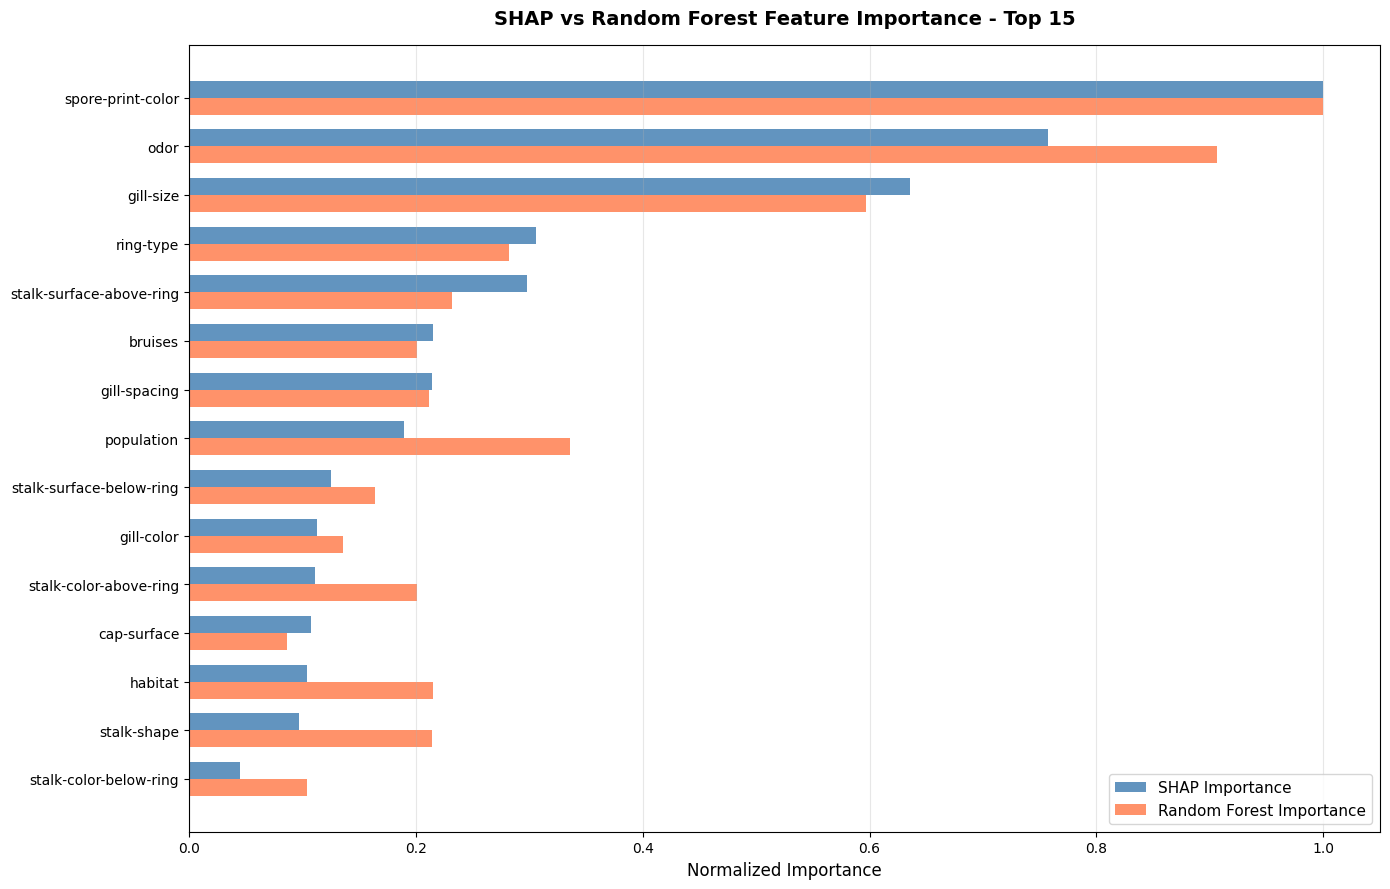


✓ Chart saved: shap_vs_rf_importance.png


In [31]:
# 5. SHAP vs RANDOM FOREST FEATURE IMPORTANCE COMPARISON

print("\n" + "="*60)
print("5. SHAP vs RANDOM FOREST FEATURE IMPORTANCE COMPARISON")
print("="*60)

rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_final.feature_importances_
})

comparison_df = importance_df[['feature', 'shap_mean']].merge(
    rf_importance_df, on='feature'
)

comparison_df['shap_rank'] = comparison_df['shap_mean'].rank(ascending=False)
comparison_df['rf_rank'] = comparison_df['rf_importance'].rank(ascending=False)
comparison_df['rank_diff'] = abs(comparison_df['shap_rank'] - comparison_df['rf_rank'])

comparison_df = comparison_df.sort_values('shap_mean', ascending=False)

print("\nTop 15 Features - Ranking comparison:")
print(comparison_df[['feature', 'shap_mean', 'rf_importance', 
                     'shap_rank', 'rf_rank', 'rank_diff']]
      .head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 9))
top_n = 15
top_features = comparison_df.head(top_n).copy()

top_features['shap_norm'] = (top_features['shap_mean'] / 
                             top_features['shap_mean'].max())
top_features['rf_norm'] = (top_features['rf_importance'] / 
                           top_features['rf_importance'].max())

x = np.arange(len(top_features))
width = 0.35

ax.barh(x - width/2, top_features['shap_norm'], width, 
        label='SHAP Importance', alpha=0.85, color='steelblue')
ax.barh(x + width/2, top_features['rf_norm'], width, 
        label='Random Forest Importance', alpha=0.85, color='coral')

ax.set_yticks(x)
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Normalized Importance', fontsize=12)
ax.set_title(f'SHAP vs Random Forest Feature Importance - Top {top_n}', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_vs_rf_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: shap_vs_rf_importance.png")

In [32]:
# CONCLUSIONS AND INSIGHTS

print("\n" + "="*60)
print("✓ SHAP ANALYSIS COMPLETED!")
print("="*60)

print("\nTOP 5 MOST IMPORTANT FEATURES (SHAP):")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']:20s} - SHAP: {row['shap_mean']:.4f}")

print("\nKEY INSIGHTS:")
print("  1. Most important features according to SHAP:")
print(f"     {', '.join(importance_df.head(3)['feature'].tolist())}")

print("\n  2. SHAP vs RF importance comparison:")
top_3_comparison = comparison_df.head(3)
for idx, row in top_3_comparison.iterrows():
    print(f"     • {row['feature']:20s}: SHAP rank #{int(row['shap_rank'])}, "
          f"RF rank #{int(row['rf_rank'])}")


✓ SHAP ANALYSIS COMPLETED!

TOP 5 MOST IMPORTANT FEATURES (SHAP):
  1. spore-print-color    - SHAP: 0.1277
  2. odor                 - SHAP: 0.0967
  3. gill-size            - SHAP: 0.0811
  4. ring-type            - SHAP: 0.0391
  5. stalk-surface-above-ring - SHAP: 0.0381

KEY INSIGHTS:
  1. Most important features according to SHAP:
     spore-print-color, odor, gill-size

  2. SHAP vs RF importance comparison:
     • spore-print-color   : SHAP rank #1, RF rank #1
     • odor                : SHAP rank #2, RF rank #2
     • gill-size           : SHAP rank #3, RF rank #3
